# Моделирование и восстановление изображений через рассеивающую среду

Данный ноутбук реализует численное моделирование прохождения когерентного света через 
тонкий случайный фазовый экран методом углового спектра (ASM), создание синтетического 
датасета на базе MNIST, обучение нейросети U-Net на PyTorch, а также классический 
алгоритм восстановления фазы Файнэпа (HIO).

Разработано для проекта по оптике (4 семестр МФТИ).

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms

from skimage.metrics import structural_similarity as ssim

# Фиксация сидов для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Выбор устройства (CUDA/MPS/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## 1. Физический движок: Метод углового спектра и фазовый экран

Здесь мы реализуем распространение комплексной амплитуды волны по уравнению Гельмгольца 
и генерацию пространственно-коррелированного фазового экрана.

In [2]:
def propagate_asm(u_in, z, wavelength, dx, device):
    """
    Распространение световой волны методом углового спектра (ASM).
    u_in: тензор формы (B, H, W) комплексной амплитуды поля
    """
    B, H, W = u_in.shape
    
    # Сетка пространственных частот
    fx = torch.fft.fftfreq(W, d=dx, device=device)
    fy = torch.fft.fftfreq(H, d=dx, device=device)
    FX, FY = torch.meshgrid(fx, fy, indexing='ij')
    
    k = 2 * np.pi / wavelength
    
    # Продольная компонента волнового вектора kz с учетом затухающих волн
    arg = k**2 - 4 * np.pi**2 * (FX**2 + FY**2)
    kz = torch.where(arg >= 0, torch.sqrt(arg), 1j * torch.sqrt(-arg))
    
    # Передаточная функция свободного пространства
    H_tf = torch.exp(1j * kz * z)
    
    # Распространение в Фурье-области
    U_in_f = torch.fft.fft2(u_in)
    U_out_f = U_in_f * H_tf
    u_out = torch.fft.ifft2(U_out_f)
    
    return u_out

def generate_phase_screen(N, dx, corr_len, sigma_phi, device):
    """
    Генерация стационарного гауссовского случайного фазового экрана
    с гауссовой автокорреляционной функцией.
    """
    # Белый шум в пространственной области
    noise = torch.randn(N, N, device=device)
    
    # Сетка координат для гауссова фильтра
    r = torch.linspace(-N*dx/2, N*dx/2, N, device=device)
    RX, RY = torch.meshgrid(r, r, indexing='ij')
    gauss_filter = torch.exp(-(RX**2 + RY**2) / (2 * corr_len**2))
    
    # Фильтрация белого шума в Фурье-домене для наведения корреляции
    noise_f = torch.fft.fft2(noise)
    filter_f = torch.fft.fft2(torch.fft.fftshift(gauss_filter))
    correlated_f = noise_f * torch.abs(filter_f)
    correlated = torch.fft.ifft2(correlated_f).real
    
    # Нормализация стандартного отклонения к заданной величине sigma_phi
    correlated = correlated / torch.std(correlated) * sigma_phi
    return correlated

def propagate_asm(u, d, wavelength, dx):
    """
    Универсальный перенос поля методом углового спектра (ASM).
    Поддерживает как батчи (B, H, W), так и одиночные матрицы (H, W).
    """
    if d == 0:
        return u
        
    N = u.shape[-1]
    device = u.device
    k = 2 * np.pi / wavelength
    
    # Генерируем сетку частот
    fx = torch.fft.fftfreq(N, d=dx, device=device)
    fxx, fyy = torch.meshgrid(fx, fx, indexing='ij')
    
    # Лекционные циклические частоты (w^2 = wx^2 + wy^2)
    w2 = (2 * np.pi * fxx)**2 + (2 * np.pi * fyy)**2
    
    # Комплексный продольный волновой вектор k_z
    k_z = torch.sqrt((k**2 - w2).to(torch.complex64))
    
    # Передаточная функция свободного пространства
    H = torch.exp(1j * d * k_z)
    
    # Перелет в частотную область, фильтрация и возврат
    U = torch.fft.fft2(u)
    return torch.fft.ifft2(U * H)

## 2. Генерация синтетического датасета спеклов на основе MNIST

Мы берем классический MNIST, приводим его к размеру $128 \times 128$, рассматриваем 
как амплитудные объекты и пропускаем через численную установку.

In [3]:
# Физические параметры численной установки
N = 128                       # Размер сетки в пикселях
dx = 4.0e-6                   # Размер пикселя, 4 мкм
wavelength = 532e-9           # Длина волны лазера, 532 нм (зеленый)
d1 = 0.001                      # Дистанция "Объект -> Рассеиватель", 1 мм
d2 = 0.002                    # Дистанция "Рассеиватель -> Камера", 2 мм
corr_len = 12.0e-6            # Радиус корреляции неоднородностей, 12 мкм
sigma_phi = 1.5 * np.pi       # Сила рассеяния экрана (стандартное отклонение фазы)

In [4]:
# Загрузка MNIST
transform = transforms.Compose([
    transforms.Resize((N, N)),
    transforms.ToTensor()
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [7]:
# Создаем ОДИН экран для ВСЕГО датасета
STATIC_PHI = generate_phase_screen(N, dx, corr_len, sigma_phi, device)
STATIC_PHASE_MASK = torch.exp(1j * STATIC_PHI)

def simulate_optical_system(images, device):
    """
    Физическая симуляция схемы: Объект -> d1 -> Стекло -> d2 -> Камера
    """
    B, C, H, W = images.shape
    u0 = images.squeeze(1).to(torch.complex64).to(device)  # Поле объекта
    
    # Шаг 1: Перелет от объекта до матового стекла на расстояние d1
    u1 = propagate_asm(u0, d1, wavelength, dx)
    
    # Шаг 2: Модуляция известным фазовым экраном
    # STATIC_PHASE_MASK имеет размер (H, W), PyTorch сам размножит её по батчу B
    u2 = u1 * STATIC_PHASE_MASK
    
    # Шаг 3: Перелет от матового стекла до камеры на расстояние d2
    u3 = propagate_asm(u2, d2, wavelength, dx)
    
    # Шаг 4: Квадратичное детектирование интенсивности
    intensity = torch.abs(u3)**2
    
    # Добавление 1% аппаратурного шума матрицы
    noise = torch.randn_like(intensity) * 0.01 * torch.max(intensity)
    intensity = torch.clamp(intensity + noise, min=0.0)
    
    # Поштучная нормализация интенсивности в [0, 1]
    min_val = intensity.view(B, -1).min(dim=1)[0].view(B, 1, 1)
    max_val = intensity.view(B, -1).max(dim=1)[0].view(B, 1, 1)
    intensity_norm = (intensity - min_val) / (max_val - min_val + 1e-8)
    
    return intensity_norm.unsqueeze(1)

### Генерация и кэширование тренировочной и валидационной выборок
Чтобы не тратить время на вычисления во время эпох обучения, сгенерируем датасет заранее.

In [8]:
def build_dataset(dataset, size=2000):
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    all_inputs = []
    all_targets = []
    
    count = 0
    for imgs, _ in tqdm(loader, desc="Генерация спеклов"):
        if count >= size:
            break
        with torch.no_grad():
            speckles = simulate_optical_system(imgs, device)
        all_inputs.append(speckles.cpu())
        all_targets.append(imgs)
        count += imgs.shape[0]
        
    return torch.cat(all_inputs)[:size], torch.cat(all_targets)[:size]

print("Генерация обучающего набора...")
X_train, Y_train = build_dataset(mnist_train, size=3000)
print("Генерация валидационного набора...")
X_val, Y_val = build_dataset(mnist_test, size=500)

class SimulatedSpeckleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = SimulatedSpeckleDataset(X_train, Y_train)
val_dataset = SimulatedSpeckleDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Генерация обучающего набора...


Генерация спеклов:   5%|▌         | 47/938 [00:01<00:24, 36.37it/s]


Генерация валидационного набора...


Генерация спеклов:   5%|▌         | 8/157 [00:00<00:03, 39.99it/s]


### Визуализация примера прямого моделирования

In [9]:
STATIC_PHI_scaled = (STATIC_PHI - STATIC_PHI.min()) / (STATIC_PHI.max() - STATIC_PHI.min() + 1e-8)
phi_list = STATIC_PHI_scaled.cpu().numpy()
phi_list = phi_list.squeeze()

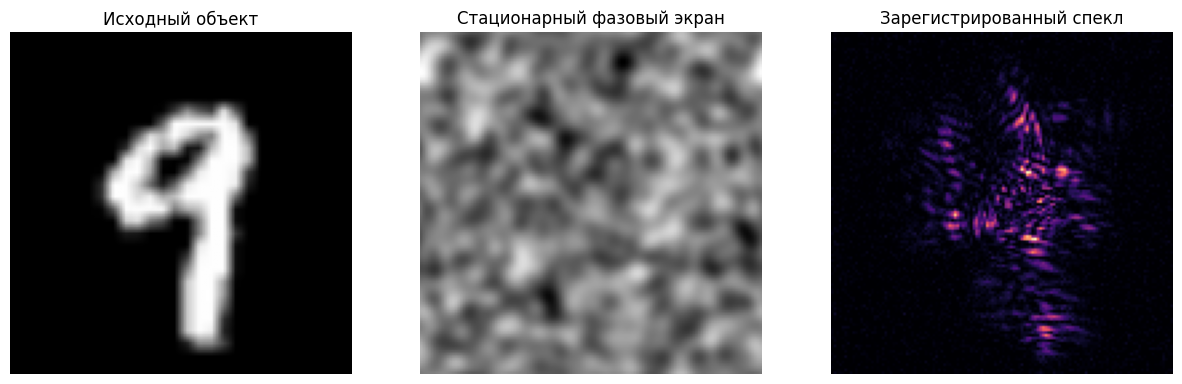

In [10]:
idx = 0

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(Y_train[idx, 0].numpy(), cmap='gray')
ax[0].set_title("Исходный объект")
ax[0].axis('off')

ax[1].imshow(phi_list, cmap='gray')
ax[1].set_title("Стационарный фазовый экран")
ax[1].axis('off')

ax[2].imshow(X_train[idx, 0].numpy(), cmap='magma')
ax[2].set_title("Зарегистрированный спекл")
ax[2].axis('off')

plt.show()

## 3. Определение архитектуры U-Net и функции потерь SSIM

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(64, 32)
        
        self.outc = nn.Conv2d(32, out_channels, kernel_size=1)
        
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        u1 = self.up1(x4)
        u1 = torch.cat([u1, x3], dim=1)
        u1 = self.conv_up1(u1)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x2], dim=1)
        u2 = self.conv_up2(u2)
        
        u3 = self.up3(u2)
        u3 = torch.cat([u3, x1], dim=1)
        u3 = self.conv_up3(u3)
        
        logits = self.outc(u3)
        return torch.sigmoid(logits)

### Дифференцируемый SSIM-Loss для обучения на PyTorch

In [12]:
def gaussian_window(window_size, sigma, device):
    gauss = torch.exp(-(torch.arange(window_size, device=device) - window_size // 2)**2 / (2 * sigma**2))
    return gauss / gauss.sum()

def create_window(window_size, channel, device):
    _1D_window = gaussian_window(window_size, 1.5, device).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = _2D_window.expand(channel, 1, window_size, window_size).contiguous()
    return window

def ssim_loss(img1, img2, window_size=11, size_average=True):
    device = img1.device
    channel = img1.size(1)
    window = create_window(window_size, channel, device)
    
    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)
    
    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2
    
    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=channel) - mu1_mu2
    
    C1 = 0.01**2
    C2 = 0.03**2
    
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    
    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.2):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        
    def forward(self, pred, target):
        loss_mse = self.mse(pred, target)
        loss_ssim = 1.0 - ssim_loss(pred, target)
        return self.alpha * loss_mse + (1.0 - self.alpha) * loss_ssim

## 4. Обучение нейросети

In [13]:
model = UNet().to(device)
criterion = HybridLoss(alpha=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

epochs = 15
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Валидация
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)
    
    print(f"Эпоха {epoch:02d}/{epochs:02d} | Train Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

Эпоха 01/15 | Train Loss: 0.68207 | Val Loss: 0.58095
Эпоха 02/15 | Train Loss: 0.31790 | Val Loss: 0.11579
Эпоха 03/15 | Train Loss: 0.08530 | Val Loss: 0.08017
Эпоха 04/15 | Train Loss: 0.06179 | Val Loss: 0.07447
Эпоха 05/15 | Train Loss: 0.05375 | Val Loss: 0.08637
Эпоха 06/15 | Train Loss: 0.04932 | Val Loss: 0.05503
Эпоха 07/15 | Train Loss: 0.04571 | Val Loss: 0.05266
Эпоха 08/15 | Train Loss: 0.04075 | Val Loss: 0.05349
Эпоха 09/15 | Train Loss: 0.03870 | Val Loss: 0.05417
Эпоха 10/15 | Train Loss: 0.03513 | Val Loss: 0.05369
Эпоха 11/15 | Train Loss: 0.03340 | Val Loss: 0.04950
Эпоха 12/15 | Train Loss: 0.03145 | Val Loss: 0.04791
Эпоха 13/15 | Train Loss: 0.02923 | Val Loss: 0.04008
Эпоха 14/15 | Train Loss: 0.02682 | Val Loss: 0.04570
Эпоха 15/15 | Train Loss: 0.02516 | Val Loss: 0.03869


### Сохранение графиков обучения для LaTeX

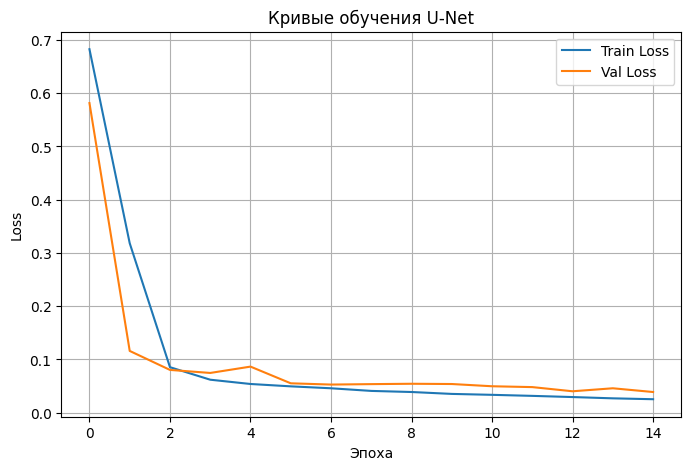

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Кривые обучения U-Net')
plt.legend()
plt.grid(True)
plt.savefig('learning_curves.png', dpi=300)
plt.show()

## 5. Реализация классического метода: Алгоритм Файнэпа (HIO)

In [15]:
def fienup_hio(speckle, num_iterations=400, beta=0.7, device='cpu'):
    """
    Итеративный алгоритм HIO во Френелевской зоне с известным фазовым экраном.
    """
    speckle_dev = speckle.to(device)
    H, W = speckle_dev.shape
    
    # Истинная амплитуда поля на матрице камеры (корень из интенсивности)
    target_amplitude = torch.sqrt(speckle_dev)
    
    # Жесткая пространственная маска (окно финитности объекта)
    support = torch.zeros((H, W), device=device)
    support[H//4 : 3*H//4, W//4 : 3*W//4] = 1.0
    
    # Начальная догадка объекта: случайная интенсивность внутри окна support
    g = torch.rand((H, W), device=device) * support
    g_prev = g.clone()
    
    for i in range(num_iterations):
        # --- ПРЯМОЙ ХОД: от догадки объекта к расчетному спеклу ---
        u1 = propagate_asm(g, d1, wavelength, dx)
        u2 = u1 * STATIC_PHASE_MASK
        u3 = propagate_asm(u2, d2, wavelength, dx)
        
        # --- ОГРАНИЧЕНИЕ НА КАМЕРЕ ---
        # Оставляем расчетную фазу поля, но жестко подменяем амплитуду на экспериментальную
        u3_prime = target_amplitude * torch.exp(1j * torch.angle(u3))
        
        # --- ОБРАТНЫЙ ХОД: крутим физику вспять ---
        # Лезем назад от камеры до стекла (расстояние -d2)
        u2_prime = propagate_asm(u3_prime, -d2, wavelength, dx)
        
        # МАТЕМАТИЧЕСКОЕ ЧУДО: «Очищаем» поле от влияния пупырышек стекла
        u1_prime = u2_prime * torch.conj(STATIC_PHASE_MASK)
        
        # Лезем назад от стекла к исходной плоскости объекта (расстояние -d1)
        # На выходе берем вещественную часть поля (физическая интенсивность объекта)
        g_prime = propagate_asm(u1_prime, -d1, wavelength, dx).real
        
        # --- ШАГ ОБНОВЛЕНИЯ HIO (Обратная связь Файнэпа) ---
        feasible = (g_prime >= 0) & (support == 1.0)
        g_next = torch.where(feasible, g_prime, g_prev - beta * g_prime)
        
        g_prev = g.clone()
        g = g_next.clone()
        
    return torch.clamp(g, min=0.0)

## 6. Сравнительный анализ и генерация результатов для отчета

In [16]:
# Выберем случайный объект из валидационного датасета для сравнения
test_idx = random.randint(0, len(val_dataset) - 1)
test_speckle, test_target = val_dataset[test_idx]

# Восстановление нейросетью U-Net
model.eval()
with torch.no_grad():
    unet_input = test_speckle.unsqueeze(0).to(device)
    unet_output = model(unet_input).cpu().squeeze(0).squeeze(0).numpy()

# Восстановление алгоритмом Файнэпа
hio_output = fienup_hio(test_speckle.squeeze(0), num_iterations=500, device=device).cpu().numpy()

# Нормализуем выходы для корректного расчета метрик
unet_output = (unet_output - unet_output.min()) / (unet_output.max() - unet_output.min() + 1e-8)
hio_output = (hio_output - hio_output.min()) / (hio_output.max() - hio_output.min() + 1e-8)
target_np = test_target.squeeze(0).numpy()

# Расчет количественных характеристик
ssim_unet = ssim(target_np, unet_output, data_range=1.0)
ssim_hio = ssim(target_np, hio_output, data_range=1.0)

mse_unet = np.mean((target_np - unet_output)**2)
mse_hio = np.mean((target_np - hio_output)**2)

print(f"Качество U-Net: SSIM = {ssim_unet:.4f}, MSE = {mse_unet:.5f}")
print(f"Качество HIO:  SSIM = {ssim_hio:.4f},  MSE = {mse_hio:.5f}")

Качество U-Net: SSIM = 0.9679, MSE = 0.00144
Качество HIO:  SSIM = 0.0244,  MSE = 0.08389


### Визуализация итогового сравнения для LaTeX-отчета

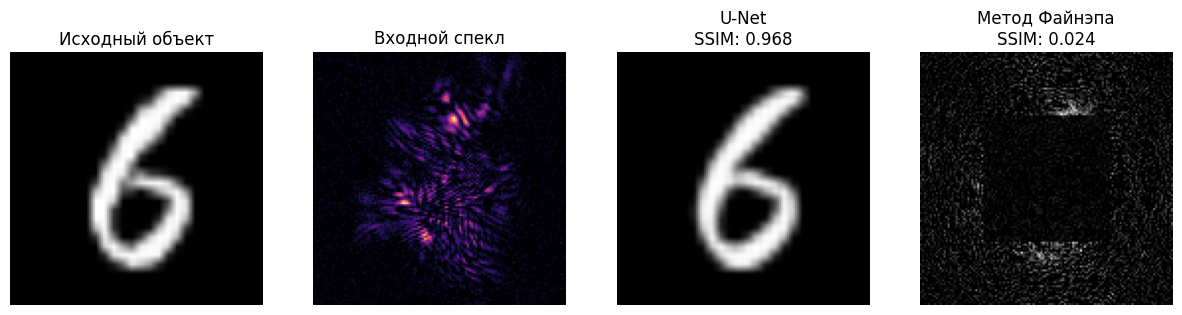

In [17]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(target_np, cmap='gray')
plt.title("Исходный объект")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(test_speckle.squeeze(0).numpy(), cmap='magma')
plt.title("Входной спекл")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(unet_output, cmap='gray')
plt.title(f"U-Net\nSSIM: {ssim_unet:.3f}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(hio_output, cmap='gray')
plt.title(f"Метод Файнэпа\nSSIM: {ssim_hio:.3f}")
plt.axis('off')

plt.savefig('comparison_results.png', dpi=300)
plt.show()

## 7. Систематический сбор метрик для финальной LaTeX-таблицы

Прогоним валидационный датасет через оба алгоритма, чтобы усреднить показатели.

In [18]:
unet_ssims, unet_mses = [], []
hio_ssims, hio_mses = [], []

# Возьмем подвыборку из 50 изображений для быстрого усреднения HIO
subset_size = 50

model.eval()
for i in tqdm(range(subset_size), desc="Вычисление общих метрик"):
    spec, targ = val_dataset[i]
    targ_np = targ.squeeze(0).numpy()
    
    # 1. Метрики U-Net
    with torch.no_grad():
        u_out = model(spec.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0).numpy()
    u_out = (u_out - u_out.min()) / (u_out.max() - u_out.min() + 1e-8)
    unet_ssims.append(ssim(targ_np, u_out, data_range=1.0))
    unet_mses.append(np.mean((targ_np - u_out)**2))
    
    # 2. Метрики HIO
    h_out = fienup_hio(spec.squeeze(0), num_iterations=400, device=device).cpu().numpy()
    h_out = (h_out - h_out.min()) / (h_out.max() - h_out.min() + 1e-8)
    hio_ssims.append(ssim(targ_np, h_out, data_range=1.0))
    hio_mses.append(np.mean((targ_np - h_out)**2))

print("\n--- Финальные усредненные результаты для таблицы LaTeX ---")
print(f"U-Net | Средний SSIM: {np.mean(unet_ssims):.4f} | Средний MSE: {np.mean(unet_mses):.5f}")
print(f"HIO   | Средний SSIM: {np.mean(hio_ssims):.4f} | Средний MSE: {np.mean(hio_mses):.5f}")

Вычисление общих метрик: 100%|██████████| 50/50 [00:35<00:00,  1.40it/s]


--- Финальные усредненные результаты для таблицы LaTeX ---
U-Net | Средний SSIM: 0.9532 | Средний MSE: 0.00221
HIO   | Средний SSIM: 0.0207 | Средний MSE: 0.09028
